Now that I have selected the templates I will find the thresholds.

In [78]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import json

from calibration_calcs import (
    dtw_cross_costs,
    plot_dtw_scatter,
    save_threshold_new_pr
)
from stft import resample_audio
from feature import load_features_from_json, make_stft_extractor

#Path to get templates
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

#Path to get calib_templates
DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"

#Path to store thresholds
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
THRESHOLDS = RESULTS / "Thresholds"

#Number of templates
file_name = "5_Templates"
n_temps = 5
n_calib = 10

#Type of feature extraction method
extractor = make_stft_extractor(frame_dur=0.064)    

In [79]:
def find_threshold_best_f1(call_costs, background_costs, n_thresholds=200, beta=1.0):
    """
    Sweep thresholds and return the one maximizing F-beta score,
    treating call_costs as positives (cost <= threshold => detected as call).
    """
    call_costs = np.array(call_costs)
    background_costs = np.array(background_costs)

    lo = min(call_costs.min(), background_costs.min())
    hi = max(call_costs.max(), background_costs.max())
    thresholds = np.linspace(lo, hi, n_thresholds)

    best_score, best_t = -1, thresholds[0]
    for t in thresholds:
        tp = np.sum(call_costs <= t)
        fp = np.sum(background_costs <= t)
        fn = np.sum(call_costs > t)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        if precision + recall == 0:
            f_score = 0
        else:
            f_score = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)

        if f_score > best_score:
            best_score, best_t = f_score, t

    return best_t, best_score

In [80]:
def compute_pr_curve_from_costs(call_costs, background_costs, n_thresholds=200):
    """
    Compute precision/recall at each threshold, sweeping over the cost range.
    Mirrors compute_roc_curve's structure but returns precision/recall instead of fpr/tpr.
    """
    call_costs = np.array(call_costs)
    background_costs = np.array(background_costs)

    lo = min(call_costs.min(), background_costs.min())
    hi = max(call_costs.max(), background_costs.max())
    thresholds = np.linspace(lo, hi, n_thresholds)

    precision, recall = [], []
    for t in thresholds:
        tp = np.sum(call_costs <= t)
        fn = np.sum(call_costs > t)
        fp = np.sum(background_costs <= t)

        precision.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

    return np.array(precision), np.array(recall), thresholds

In [81]:
def find_threshold_best_f1_from_pr(precision, recall, thresholds, beta=1.0):
    """Given precision/recall/thresholds (from compute_pr_curve_from_costs), find the best F-beta point."""
    with np.errstate(divide="ignore", invalid="ignore"):
        f_scores = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)
    f_scores = np.nan_to_num(f_scores, nan=0.0)

    best_idx = np.argmax(f_scores)
    return thresholds[best_idx], f_scores[best_idx]

In [82]:
def plot_pr_curve_from_costs(call_costs, background_costs, n_thresholds=200,
                              best_threshold=None, ax=None):
    precision, recall, thresholds = compute_pr_curve_from_costs(call_costs, background_costs, n_thresholds)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(recall, precision, color="tab:blue", linewidth=2, label="PR curve")

    if best_threshold is not None:
        idx = np.argmin(np.abs(thresholds - best_threshold))
        ax.scatter(recall[idx], precision[idx], color="red", zorder=5,
                   label=f"Chosen threshold = {best_threshold:.3f}")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve: DTW-based Call Detection")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

    if standalone:
        plt.show()

    return precision, recall, thresholds

In [83]:
def load_entries(path, n=None):
    with open(path) as f:
        return json.load(f)[:n]

In [84]:
def load_template_features_fixed_length(entry, extractor, window_len, fs_new=1000):
    """
    Like load_segment_features, but centers/pads the segment to exactly
    window_len seconds instead of using the call's own start/end duration.
    """
    with sf.SoundFile(entry["wav_path"]) as f:
        f_s = f.samplerate
        call_start, call_end = entry["start_time"], entry["end_time"]
        call_center = (call_start + call_end) / 2

        half_len = window_len / 2
        seg_start = max(0.0, call_center - half_len)
        seg_end = seg_start + window_len

        start_sample = int(seg_start * f_s)
        end_sample = int(seg_end * f_s)
        f.seek(start_sample)
        segment = f.read(end_sample - start_sample, dtype="int16")

    audio = resample_audio(segment, f_s, fs_new)

    target_len = int(fs_new * window_len)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)), mode="constant")
    elif len(audio) > target_len:
        audio = audio[:target_len]

    return extractor(audio, fs_new)

In [85]:
frame_dur = 0.128
hop = frame_dur * (1 - 0.75)   # 0.032 s
min_frames = 10 #for MFCC deltas

floor = frame_dur + (min_frames - 1) * hop
print(floor)   # 0.352 s

0.41600000000000004


In [86]:
"""
Load the audio file and its annotation/selection text file for recording 22,
then compute min/max/mean call duration using call_length_stats.
Tonal downsweeps (TD) are excluded from the 22 file's stats.
"""

from pathlib import Path
from background_functions import read_audio_file, start_end_times, call_length_stats

#Path to get calib_templates
DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
wav_path_26 = DATA_26 / "20230426_075505.wav"
text_path_26 = DATA_26 / "2023-04-26T07-55-05_000_00072.txt"

f_s, x = read_audio_file(wav_path_26)
aud_26, start_t, end_t = start_end_times(text_path_26)

avg_26, max_26, min_26 = call_length_stats(aud_26)

print("File name: 20230426_075505.wav")
print(f"Number of calls: {len(aud_26)}")
print(f"Mean call length:     {avg_26:.3f} s")
print(f"Longest call length:  {max_26:.3f} s")
print(f"Shortest call length: {min_26:.3f} s")

File name: 20230426_075505.wav
Number of calls: 342
Mean call length:     0.246 s
Longest call length:  0.645 s
Shortest call length: 0.097 s


In [87]:
#start of filename where templates are stored
TEMPLATE_filename_start = "20230429_Templates_20230429_102841"

#Create item() for call type file_names
#"call_type" : "calib_file"
CALIB_FILES = {
    "single_tone": "ST_CALIB_26_20230426_075505_single_tone_templates.json",
    "multi_tone":  "MT_CALIB_26_20230426_075505_multi_tone_templates.json",
    "burst_tonal": "BT_CALIB_26_20230426_075505_burst_tonal_templates.json",
}

bg_file = "Bground_CALIB_26_20230426_075505_background.json"

window_len=0.09 [single_tone]: threshold=0.1501  F1=0.9901
window_len=0.09 [multi_tone]: threshold=0.1906  F1=0.7961
window_len=0.09 [burst_tonal]: threshold=0.1801  F1=0.8431


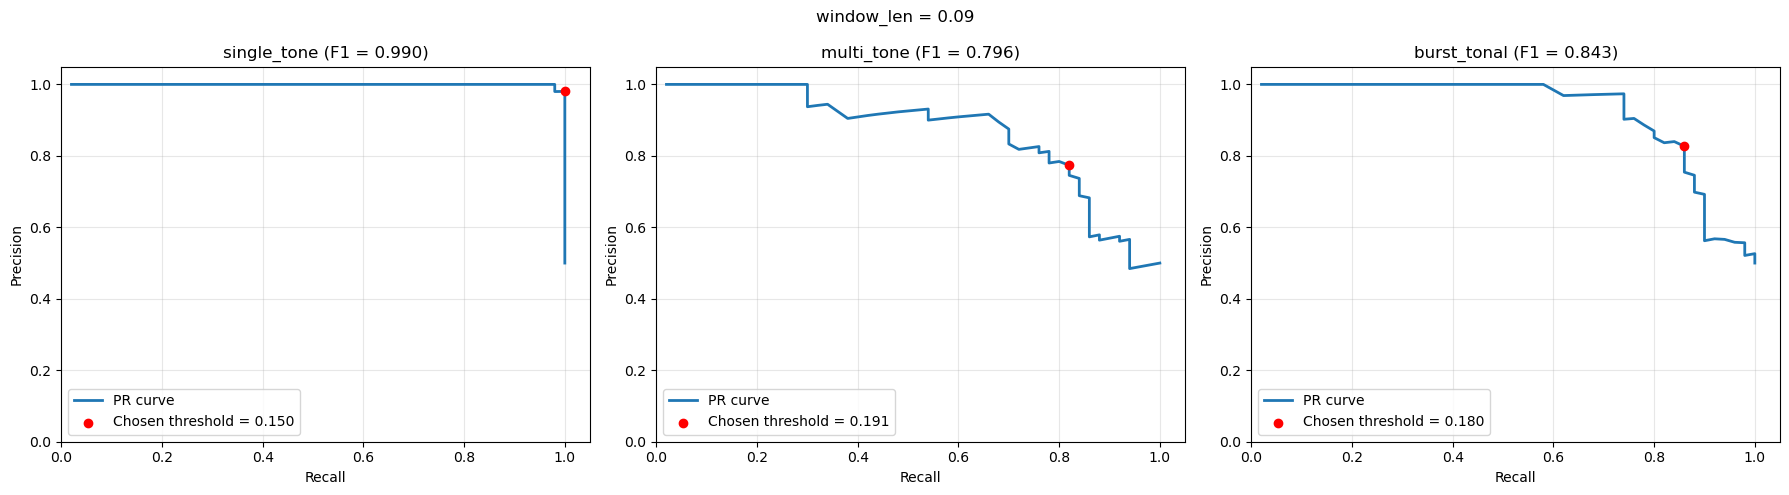

window_len=0.1 [single_tone]: threshold=0.1399  F1=0.9899
window_len=0.1 [multi_tone]: threshold=0.1698  F1=0.8298
window_len=0.1 [burst_tonal]: threshold=0.1618  F1=0.9184


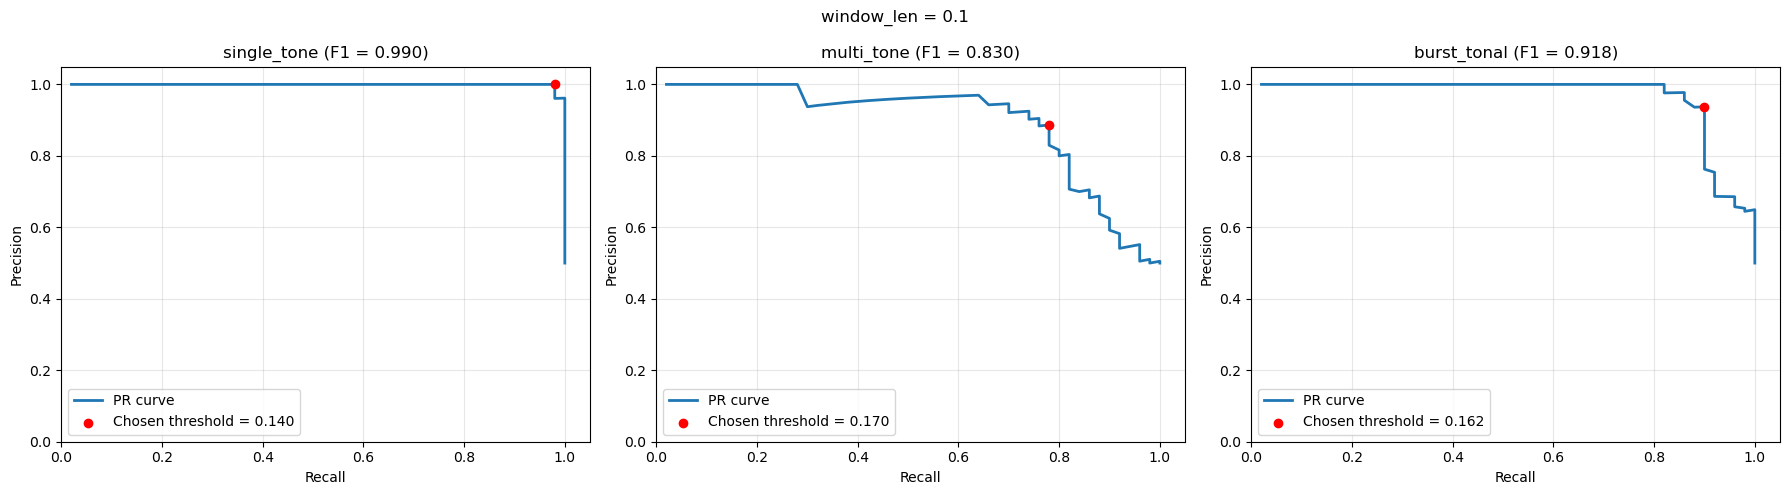

window_len=0.2 [single_tone]: threshold=0.1236  F1=0.9800
window_len=0.2 [multi_tone]: threshold=0.1338  F1=0.8046
window_len=0.2 [burst_tonal]: threshold=0.1398  F1=0.9293


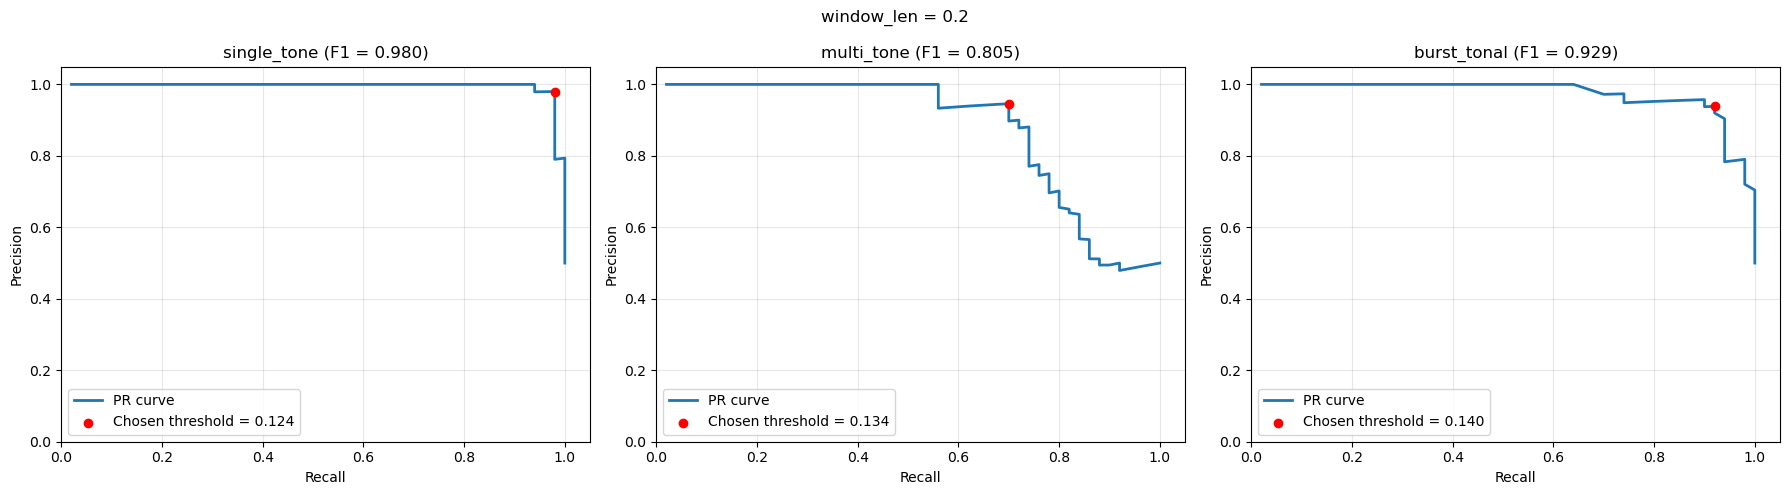

window_len=0.3 [single_tone]: threshold=0.1281  F1=1.0000
window_len=0.3 [multi_tone]: threshold=0.1312  F1=0.8261
window_len=0.3 [burst_tonal]: threshold=0.1342  F1=0.9495


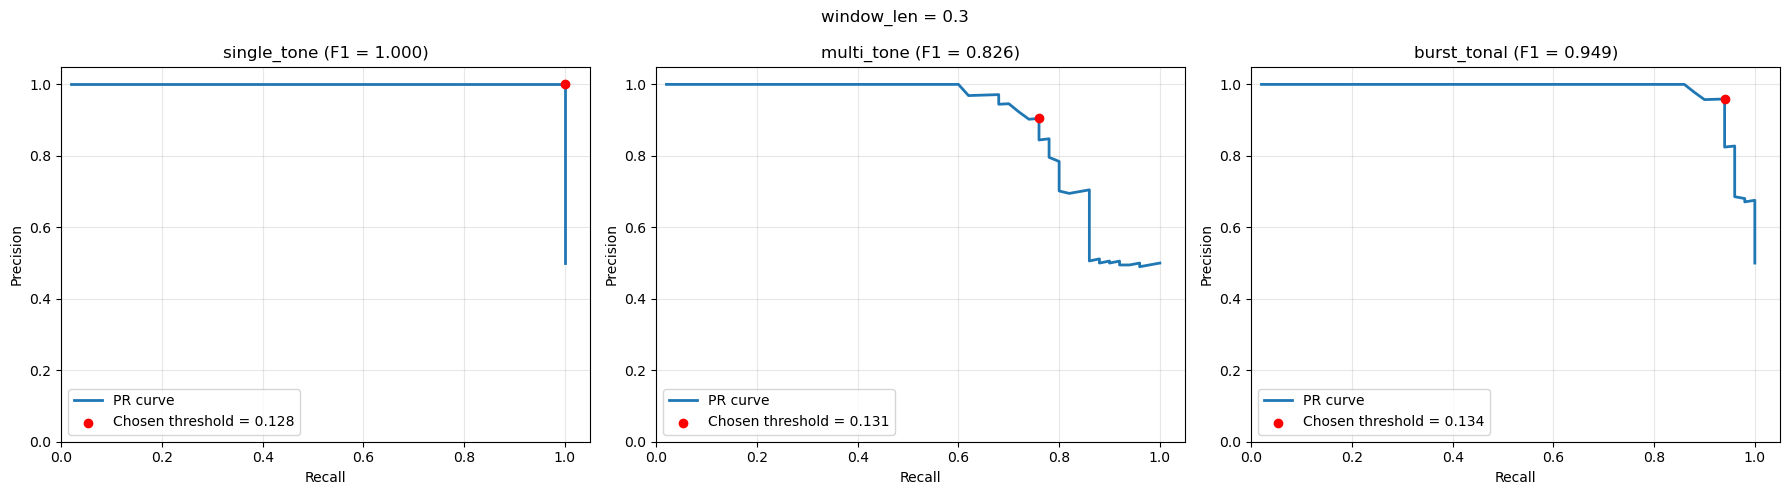

window_len=0.4 [single_tone]: threshold=0.1088  F1=0.9899
window_len=0.4 [multi_tone]: threshold=0.1202  F1=0.8636
window_len=0.4 [burst_tonal]: threshold=0.1359  F1=0.9608


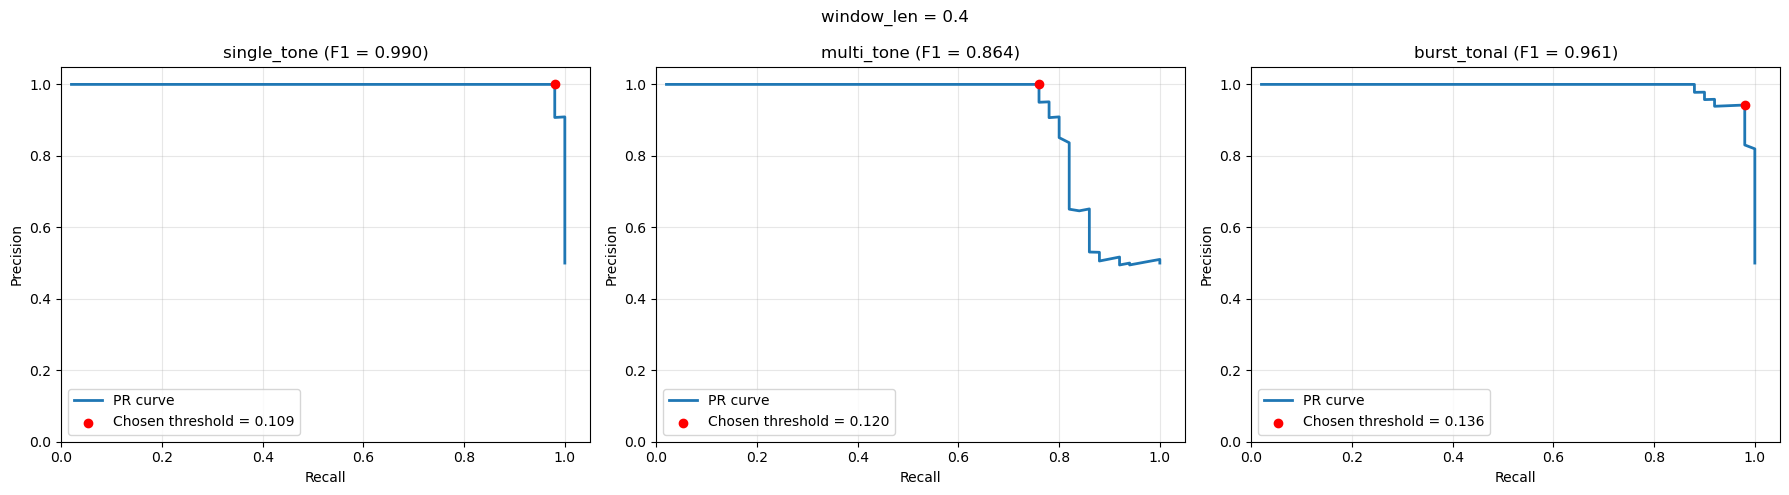

window_len=0.5 [single_tone]: threshold=0.1081  F1=0.9899
window_len=0.5 [multi_tone]: threshold=0.1264  F1=0.8764
window_len=0.5 [burst_tonal]: threshold=0.1300  F1=0.9388


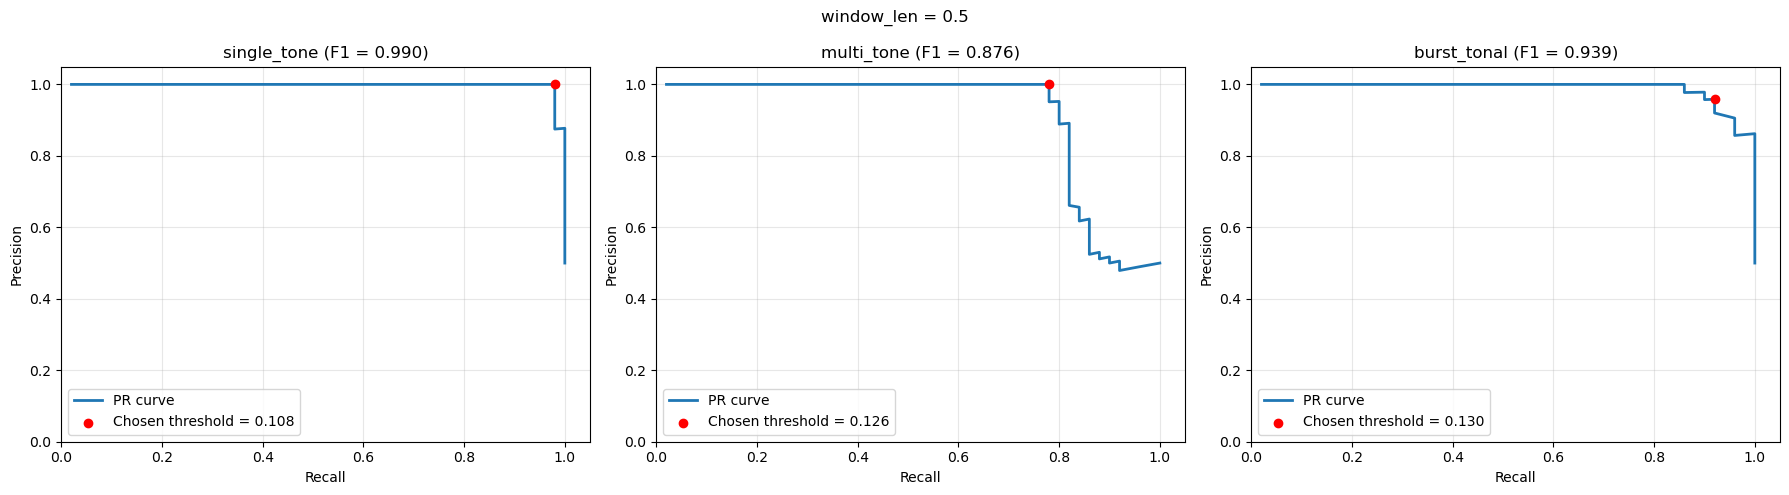

window_len=0.6 [single_tone]: threshold=0.1107  F1=0.9899
window_len=0.6 [multi_tone]: threshold=0.1272  F1=0.8667
window_len=0.6 [burst_tonal]: threshold=0.1234  F1=0.9583


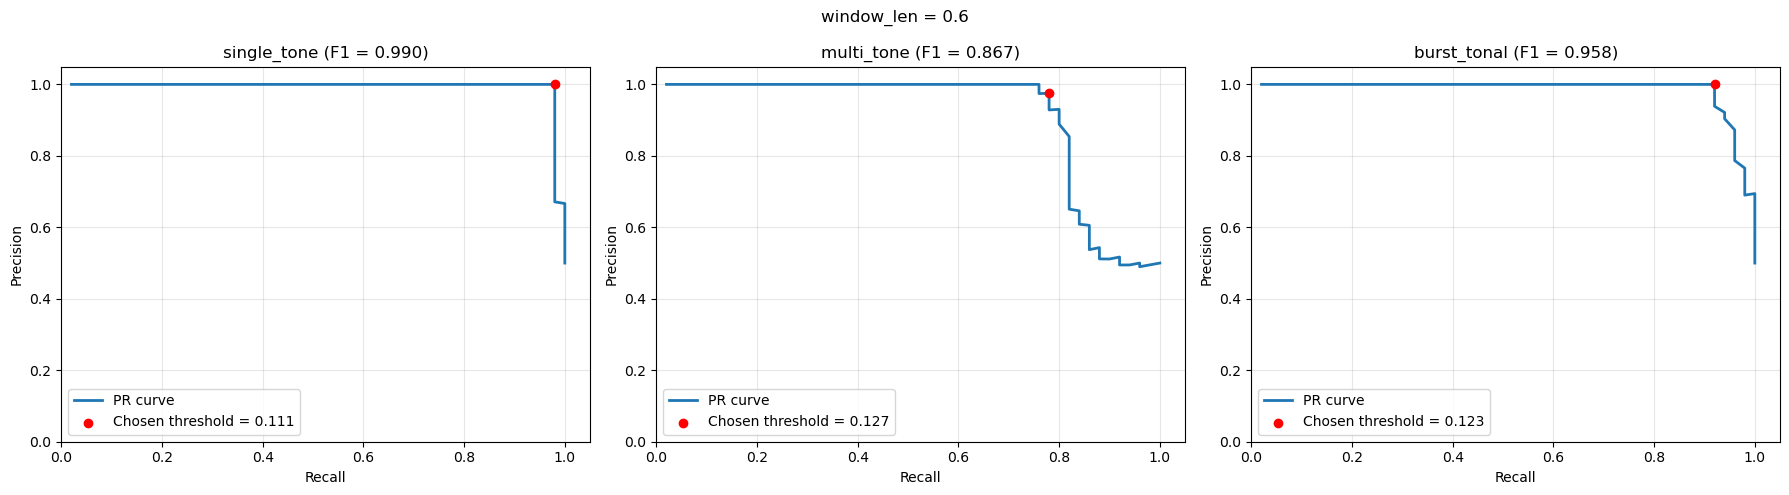

window_len=0.7 [single_tone]: threshold=0.1220  F1=0.9899
window_len=0.7 [multi_tone]: threshold=0.1293  F1=0.8764
window_len=0.7 [burst_tonal]: threshold=0.1306  F1=0.9697


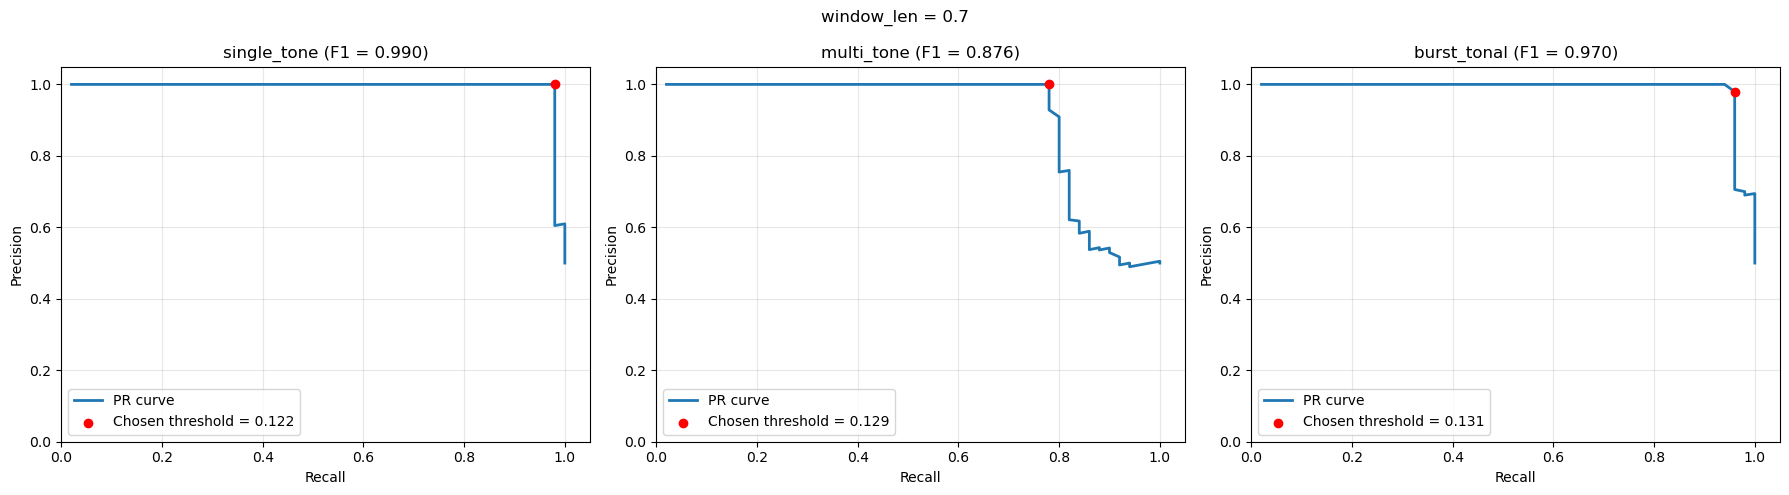

window_len=0.09: min F1 = 0.7961
window_len=0.1: min F1 = 0.8298
window_len=0.2: min F1 = 0.8046
window_len=0.3: min F1 = 0.8261
window_len=0.4: min F1 = 0.8636
window_len=0.5: min F1 = 0.8764
window_len=0.6: min F1 = 0.8667
window_len=0.7: min F1 = 0.8764
Chosen window_len = 0.5


In [90]:
window_lengths_to_test = [0.09 ,0.1 ,0.2 ,0.3, 0.4, 0.5, 0.6, 0.7]
window_results = {}   # window_len -> {call_type: f1}

bg_entries = load_entries(RESULTS_26 / bg_file, n_calib)

for window_len in window_lengths_to_test:
    bg_feats = [load_template_features_fixed_length(e, extractor, window_len) for e in bg_entries]
    window_results[window_len] = {}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (call_type, calib_file) in zip(axes, CALIB_FILES.items()):
        calib_entries = load_entries(RESULTS_26 / calib_file, n_calib)

        template_feats = load_features_from_json(RESULTS_29 / f"{TEMPLATE_filename_start}_{call_type}_templates.json", extractor, n_temps)
        calib_feats = [load_template_features_fixed_length(e, extractor, window_len) for e in calib_entries]

        call_costs = dtw_cross_costs(template_feats, calib_feats, extractor.metric)
        bg_costs = dtw_cross_costs(template_feats, bg_feats, extractor.metric)

        precision, recall, pr_thresholds = compute_pr_curve_from_costs(call_costs, bg_costs)
        threshold, f1 = find_threshold_best_f1_from_pr(precision, recall, pr_thresholds)
        plot_pr_curve_from_costs(call_costs, bg_costs, best_threshold=threshold, ax=ax)
        ax.set_title(f"{call_type} (F1 = {f1:.3f})")
        window_results[window_len][call_type] = f1
        print(f"window_len={window_len} [{call_type}]: threshold={threshold:.4f}  F1={f1:.4f}")
    fig.suptitle(f"window_len = {window_len}")
    plt.tight_layout()
    plt.show()


# pick the window length with the best worst-case F1 across the three call types
for window_len, f1s in window_results.items():
    print(f"window_len={window_len}: min F1 = {min(f1s.values()):.4f}")
best_window_len = max(window_results, key=lambda w: min(window_results[w].values()))
print(f"Chosen window_len = {best_window_len}")

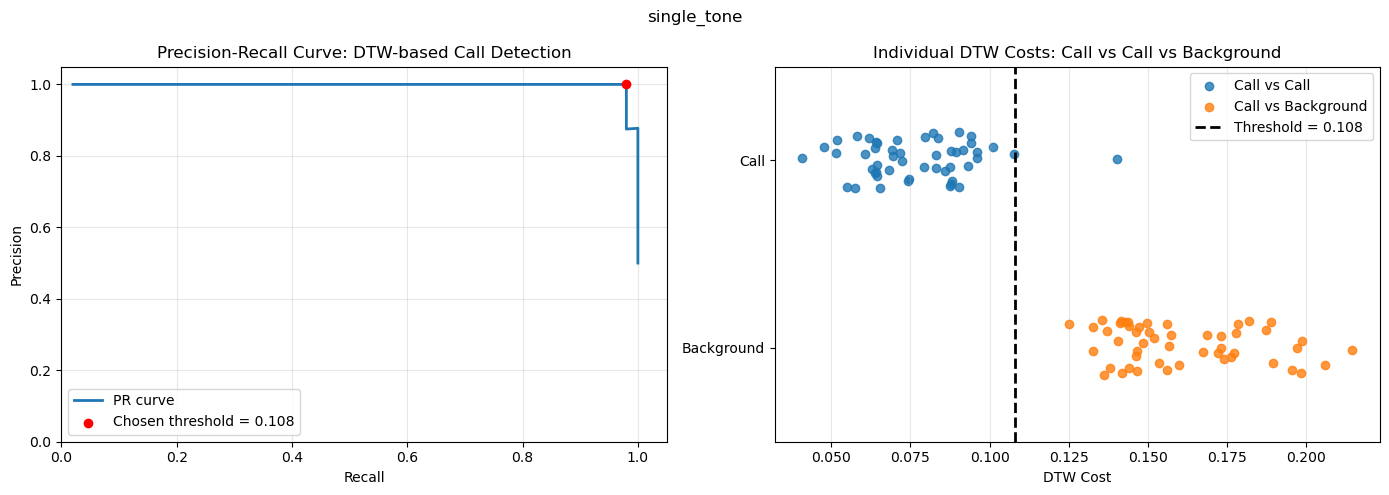

Saved threshold for 'single_tone' [stft] to 5_Templates_stft_single_tone_threshold.json: threshold=0.1081, f1=0.9899


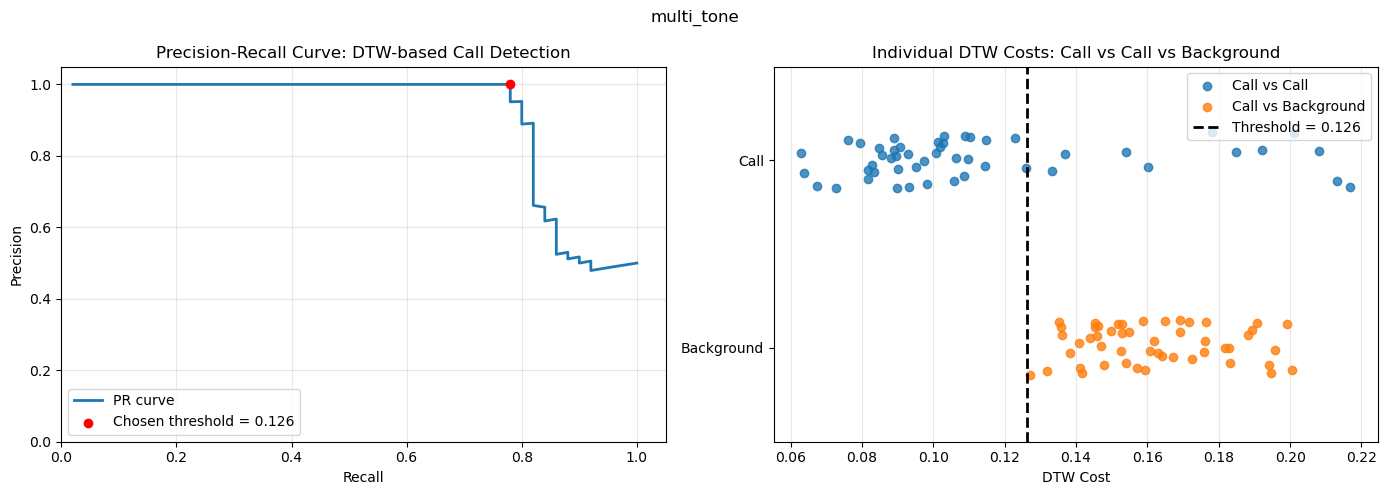

Saved threshold for 'multi_tone' [stft] to 5_Templates_stft_multi_tone_threshold.json: threshold=0.1264, f1=0.8764


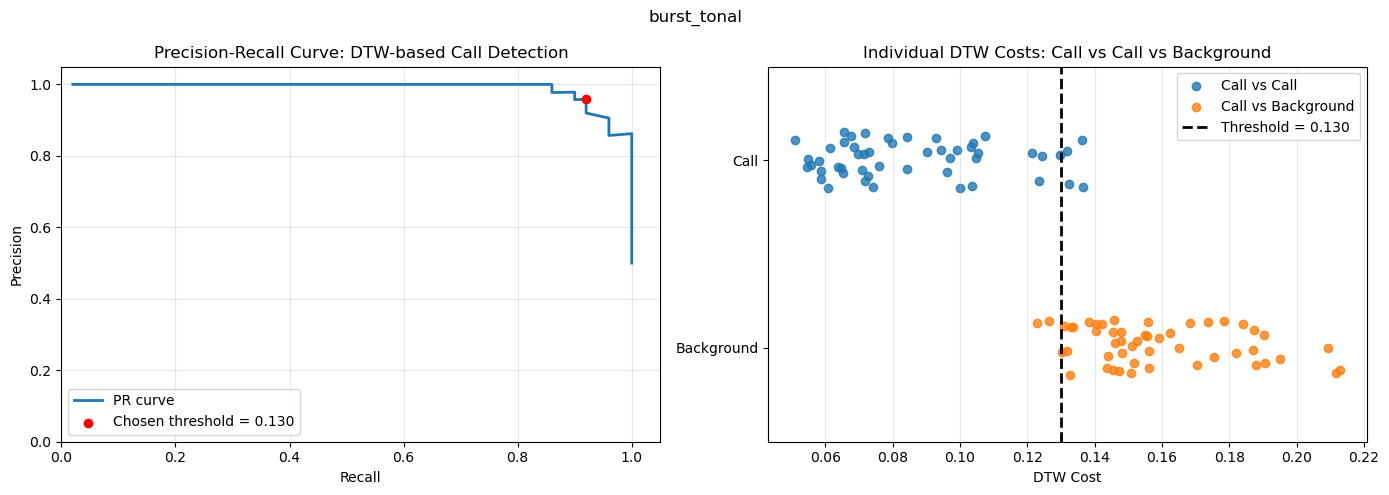

Saved threshold for 'burst_tonal' [stft] to 5_Templates_stft_burst_tonal_threshold.json: threshold=0.1300, f1=0.9388


In [89]:
bg_feats = [load_template_features_fixed_length(e, extractor, best_window_len) for e in bg_entries]

for call_type, calib_file in CALIB_FILES.items():
    calib_entries = load_entries(RESULTS_26 / calib_file, n_calib)

    template_feats = load_features_from_json(RESULTS_29 / f"{TEMPLATE_filename_start}_{call_type}_templates.json", extractor, n_temps)
    calib_feats = [load_template_features_fixed_length(e, extractor, best_window_len) for e in calib_entries]

    call_costs = dtw_cross_costs(template_feats, calib_feats, extractor.metric)
    bg_costs = dtw_cross_costs(template_feats, bg_feats, extractor.metric)

    precision, recall, pr_thresholds = compute_pr_curve_from_costs(call_costs, bg_costs)
    threshold, f1 = find_threshold_best_f1_from_pr(precision, recall, pr_thresholds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_pr_curve_from_costs(call_costs, bg_costs, best_threshold=threshold, ax=axes[0])
    plot_dtw_scatter(call_costs, bg_costs, threshold=threshold, ax=axes[1])
    fig.suptitle(f"{call_type}")
    plt.tight_layout()
    plt.show()

    save_threshold_new_pr(threshold, f1, call_type=call_type,
               score_name="f1",
               file_label=file_name, results_dir=THRESHOLDS,
               n_templates=n_temps, n_background=n_calib,
               feature_name=extractor.name, feature_params=extractor.params)